# DINOv3
---

## Celda 1 — Instalación, Importación y Login a Hugging Face

In [ ]:
!pip install -q --upgrade "transformers>=4.56.0" huggingface_hub timm
import io
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2                          # OpenCV para manipulación de imagen
from PIL import Image               # Pillow para carga/conversión

# ── Deep Learning ─────────────────────────────────────────────
import torch

# ── Hugging Face Transformers ──────────────────────────────────
from transformers import AutoImageProcessor, AutoModel
from huggingface_hub import notebook_login

# ── Análisis de Componentes Principales ───────────────────────
from sklearn.decomposition import PCA

# ── Configuración general ──────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Librerías cargadas correctamente.")
print(f"🖥️  Dispositivo detectado: {DEVICE}")
print(f"🔥 PyTorch versión: {torch.__version__}")

# ── Login a Hugging Face (necesario: repo gated) ───────────────
print("\n🔑 Inicia sesión con tu token de Hugging Face (lectura 'Read' es suficiente):")
notebook_login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 48.1 MB/s eta 0:00:00
✅ Librerías cargadas correctamente.
🖥️  Dispositivo detectado: cuda
🔥 PyTorch versión: 2.11.0+cu128

🔑 Inicia sesión con tu token de Hugging Face (lectura 'Read' es suficiente):


## Celda 2 — Carga del Modelo DINOv3

In [ ]:
MODEL_NAME = "facebook/dinov3-vits16-pretrain-lvd1689m"

print(f"📥 Descargando modelo: {MODEL_NAME} ...")

# AutoImageProcessor: preprocesador oficial del modelo
# Incluye resize, normalización con media/std de ImageNet-1k
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

# AutoModel: carga los pesos del ViT sin cabeza de clasificación
model = AutoModel.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)   # Mover al GPU si está disponible
model.eval()               # Modo evaluación: desactiva dropout, etc.

# Datos de arquitectura relevantes para los siguientes pasos
PATCH_SIZE = model.config.patch_size              # 16 px por patch
NUM_REGISTER_TOKENS = model.config.num_register_tokens  # tokens "extra" de DINOv3

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo '{MODEL_NAME}' cargado correctamente.")
print(f"📊 Parámetros totales : {total_params / 1e6:.1f}M")
print(f"🧩 Patch size         : {PATCH_SIZE}x{PATCH_SIZE} px")
print(f"🏷️  Tokens de registro : {NUM_REGISTER_TOKENS}  (novedad de DINOv3 frente a v2)")

📥 Descargando modelo: facebook/dinov3-vits16-pretrain-lvd1689m ...


preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

✅ Modelo 'facebook/dinov3-vits16-pretrain-lvd1689m' cargado correctamente.
📊 Parámetros totales : 21.6M
🧩 Patch size         : 16x16 px
🏷️  Tokens de registro : 4  (novedad de DINOv3 frente a v2)


## Celda 3 — Carga de la Imagen de Prueba

📸 Descargando imagen desde:
   https://images.unsplash.com/photo-1500595046743-cd271d694d30?q=80&w=1740&auto=format&fit=crop
✅ Imagen descargada. Tamaño original: (1740, 1156) (ancho x alto)


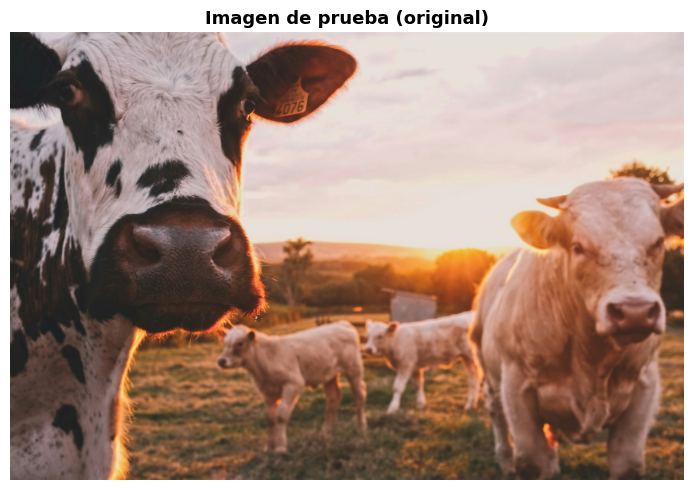

In [ ]:
IMAGE_URL = "https://images.unsplash.com/photo-1500595046743-cd271d694d30?q=80&w=1740&auto=format&fit=crop"
print(f"📸 Descargando imagen desde:\n   {IMAGE_URL}")
response = requests.get(IMAGE_URL, timeout=15)
response.raise_for_status()  # Lanza error si falla la descarga

image_pil = Image.open(io.BytesIO(response.content)).convert("RGB")

print(f"✅ Imagen descargada. Tamaño original: {image_pil.size} (ancho x alto)")

# ── Visualización rápida ────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.imshow(image_pil)
plt.title("Imagen de prueba (original)", fontsize=13, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()

## Celda 4 — Preprocesamiento de la Imagen

In [ ]:
IMG_SIZE = 512    # 512 = 32 * 16  →  32x32 grid de patches

# ── Preprocesamiento con el procesador oficial ──────────────
# return_tensors="pt" → devuelve tensores PyTorch listos para el modelo
inputs = processor(
    images=image_pil,
    return_tensors="pt",
    size={"height": IMG_SIZE, "width": IMG_SIZE}
)

# Movemos el tensor de entrada al mismo dispositivo que el modelo
pixel_values = inputs["pixel_values"].to(DEVICE)  # shape: [1, 3, 512, 512]

# ── Imagen redimensionada para visualización ────────────────
# La guardamos en numpy (H, W, C) para usarla en matplotlib
image_resized = np.array(image_pil.resize((IMG_SIZE, IMG_SIZE)))

# ── Calculamos el grid de patches ───────────────────────────
n_patches_side = IMG_SIZE // PATCH_SIZE   # 512 // 16 = 32
n_patches_total = n_patches_side ** 2     # 32 * 32 = 1024 patches

print(f"✅ Preprocesamiento completado.")
print(f"   Tensor de entrada: {list(pixel_values.shape)}  [batch, canales, alto, ancho]")
print(f"   Grid de patches  : {n_patches_side} x {n_patches_side} = {n_patches_total} patches")
print(f"   Cada patch cubre : {PATCH_SIZE}x{PATCH_SIZE} píxeles de la imagen")

✅ Preprocesamiento completado.
   Tensor de entrada: [1, 3, 512, 512]  [batch, canales, alto, ancho]
   Grid de patches  : 32 x 32 = 1024 patches
   Cada patch cubre : 16x16 píxeles de la imagen


## Celda 5 — Inferencia: Extracción de Características

In [ ]:
with torch.no_grad():
    outputs = model(pixel_values=pixel_values)

# ── Extraemos el tensor de características ────────────────────
last_hidden = outputs.last_hidden_state
hidden_dim = last_hidden.shape[-1]

# Índice donde empiezan los patch tokens (saltamos CLS + registros)
patch_start_idx = 1 + NUM_REGISTER_TOKENS

cls_token    = last_hidden[:, 0, :]
register_tok = last_hidden[:, 1:patch_start_idx, :]
patch_tokens = last_hidden[:, patch_start_idx:, :]

patch_features = patch_tokens.squeeze(0).cpu().numpy()

print(f"✅ Inferencia completada.")
print(f"   Secuencia completa : {list(last_hidden.shape)}")
print(f"   CLS token          : {list(cls_token.shape)}  → 1 vector que resume TODA la imagen")
print(f"   Tokens de registro : {list(register_tok.shape)}  → descartados (sin info espacial)")
print(f"   Patch tokens       : {patch_features.shape}  → {patch_features.shape[0]} regiones x {patch_features.shape[1]} dimensiones")
print(f"\n   💡 Cada una de las {patch_features.shape[0]} filas es un vector de {patch_features.shape[1]} números")
print(f"      que describe semánticamente un parche de {PATCH_SIZE}x{PATCH_SIZE}px de la imagen.")

🚀 Ejecutando inferencia con DINOv3...
✅ Inferencia completada.
   Secuencia completa : [1, 1029, 384]
   CLS token          : [1, 384]  → 1 vector que resume TODA la imagen
   Tokens de registro : [1, 4, 384]  → descartados (sin info espacial)
   Patch tokens       : (1024, 384)  → 1024 regiones x 384 dimensiones

   💡 Cada una de las 1024 filas es un vector de 384 números
      que describe semánticamente un parche de 16x16px de la imagen.


## Celda 6 — Visualización con PCA

📈 PCA-1 conserva el 21.2% de la variación total entre patches
📈 PCA-3 conserva el 44.9% de la variación total entre patches
   (de los 384 valores originales por patch, comprimidos a 1 y 3 respectivamente)


/tmp/ipykernel_4408/55589646.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_4408/55589646.py:102: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.savefig("dinov3_pca_visualization.png", dpi=150, bbox_inches='tight')
/tmp/ipykernel_4408/55589646.py:102: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.savefig("dinov3_pca_visualization.png", dpi=150, bbox_inches='tight')
/tmp/ipykernel_4408/55589646.py:102: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig("dinov3_pca_visualization.png", dpi=150, bbox_inches='tight')
/tmp/ipykernel_4408/55589646.py:102: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.savefig("dinov3_pca_visualization.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/

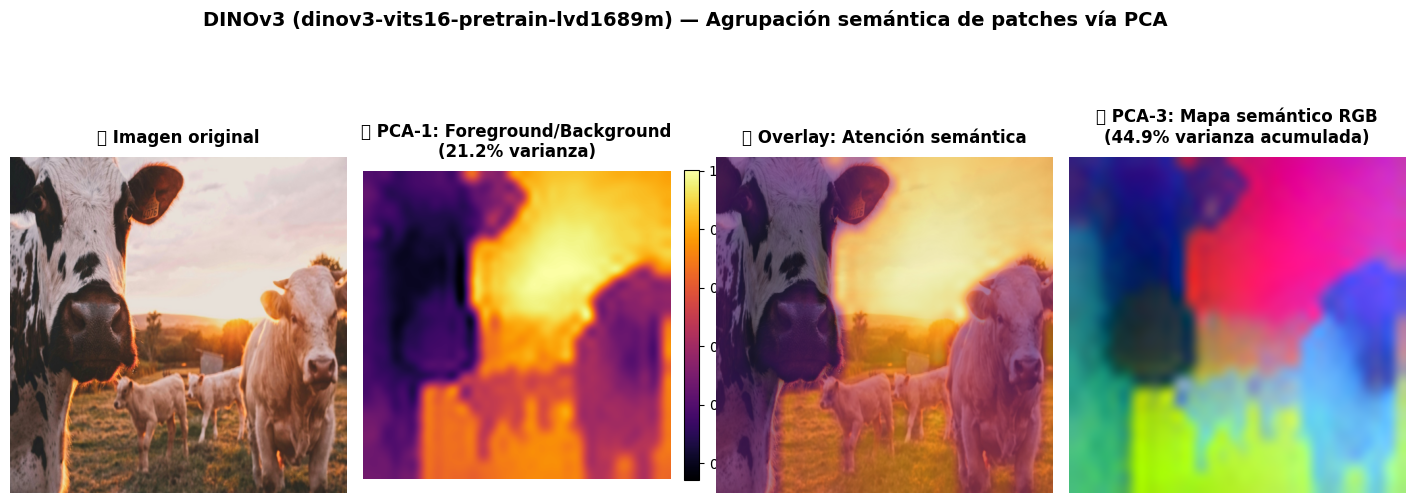


✅ Visualización completada. Archivo guardado como 'dinov3_pca_visualization.png'


In [ ]:
pca_1 = PCA(n_components=1)
pca_1_result = pca_1.fit_transform(patch_features)  # [1024, 384] → [1024, 1]

heatmap_raw = pca_1_result.reshape(n_patches_side, n_patches_side)

heatmap_norm = (heatmap_raw - heatmap_raw.min()) / (heatmap_raw.max() - heatmap_raw.min())

heatmap_display = cv2.resize(
    heatmap_norm,
    (IMG_SIZE, IMG_SIZE),
    interpolation=cv2.INTER_LANCZOS4
)

pca_3 = PCA(n_components=3)
pca_3_result = pca_3.fit_transform(patch_features)  # [1024, 384] → [1024, 3]

# Normalizamos cada componente (cada "canal") de forma independiente a [0,1]
def normalize_component(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

rgb_map = np.stack([
    normalize_component(pca_3_result[:, 0]),  # componente 1 → canal R (rojo)
    normalize_component(pca_3_result[:, 1]),  # componente 2 → canal G (verde)
    normalize_component(pca_3_result[:, 2]),  # componente 3 → canal B (azul)
], axis=-1)  # [1024, 3]

rgb_map = rgb_map.reshape(n_patches_side, n_patches_side, 3)

rgb_display = cv2.resize(
    rgb_map,
    (IMG_SIZE, IMG_SIZE),
    interpolation=cv2.INTER_LANCZOS4
)

var_explained_1 = pca_1.explained_variance_ratio_[0] * 100
var_explained_3 = pca_3.explained_variance_ratio_.sum() * 100

print(f"📈 PCA-1 conserva el {var_explained_1:.1f}% de la variación total entre patches")
print(f"📈 PCA-3 conserva el {var_explained_3:.1f}% de la variación total entre patches")
print(f"   (de los 384 valores originales por patch, comprimidos a 1 y 3 respectivamente)")

# ── Visualización Final: 4 paneles lado a lado ──────────────────
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.05)

# Panel 1: Imagen original (referencia)
ax1 = fig.add_subplot(gs[0])
ax1.imshow(image_resized)
ax1.set_title("📷 Imagen original", fontsize=12, fontweight='bold', pad=10)
ax1.axis("off")

# Panel 2: Mapa de calor PCA-1 (foreground vs background)
ax2 = fig.add_subplot(gs[1])
im2 = ax2.imshow(heatmap_display, cmap="inferno")
ax2.set_title(
    f"🌡️ PCA-1: Foreground/Background\n({var_explained_1:.1f}% varianza)",
    fontsize=12, fontweight='bold', pad=10
)
ax2.axis("off")
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# Panel 3: Overlay — heatmap superpuesto a la imagen original (más intuitivo)
ax3 = fig.add_subplot(gs[2])
ax3.imshow(image_resized)
ax3.imshow(heatmap_display, cmap="inferno", alpha=0.55)  # alpha = transparencia
ax3.set_title("🔍 Overlay: Atención semántica", fontsize=12, fontweight='bold', pad=10)
ax3.axis("off")

# Panel 4: Mapa semántico a color (PCA-3 como RGB)
ax4 = fig.add_subplot(gs[3])
ax4.imshow(rgb_display)
ax4.set_title(
    f"🎨 PCA-3: Mapa semántico RGB\n({var_explained_3:.1f}% varianza acumulada)",
    fontsize=12, fontweight='bold', pad=10
)
ax4.axis("off")

fig.suptitle(
    f"DINOv3 ({MODEL_NAME.split('/')[-1]}) — Agrupación semántica de patches vía PCA",
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig("dinov3_pca_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualización completada. Archivo guardado como 'dinov3_pca_visualization.png'")